Assignment (03/04/2026)

Assignment Name : NLP Mini App
Description : Build a chatbot, fake news detector, or keyword extractor.

In [ ]:
#App1 Chatbot

# Cell 1 — Install & Import
!pip install nltk
import nltk, re, string
nltk.download('punkt')
nltk.download('stopwords')

# Cell 2 — Define Responses
responses = {
    r'hello|hi|hey':          'Hello! How can I help you today?',
    r'your name':             'I am NLP Bot, your AI assistant.',
    r'how are you':           'I am doing great! Thanks for asking.',
    r'weather':               'I cannot check live weather, but try weather.com!',
    r'bye|goodbye|exit':      'Goodbye! Have a great day!',
    r'help':                  'I can answer basic questions. Try asking me anything!',
}

# Cell 3 — Chatbot Logic (with intent detection)
def chatbot(user_input):
    user_input = user_input.lower().strip()
    
    for pattern, reply in responses.items():
        if re.search(pattern, user_input):
            return pattern, reply   # returning matched pattern (intent)
    
    return "unknown", 'Sorry, I did not understand that. Can you rephrase?'

# Cell 4 — Run Chatbot
print('NLP Chatbot (type "bye" to quit)')
while True:
    user = input('You: ')
    
    intent, response = chatbot(user)
    
    print(f'Identified Intent: {intent}')
    print(f'Bot: {response}')
    
    if re.search(r'bye|goodbye|exit', user.lower()):
        break

DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aasch\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aasch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Defaulting to user installation because normal site-packages is not writeable
NLP Chatbot (type "bye" to quit)
Identified Intent: hello|hi|hey
Bot: Hello! How can I help you today?
Identified Intent: your name
Bot: I am NLP Bot, your AI assistant.
Identified Intent: how are you
Bot: I am doing great! Thanks for asking.
Identified Intent: weather
Bot: I cannot check live weather, but try weather.com!
Identified Intent: bye|goodbye|exit
Bot: Goodbye! Have a great day!


In [ ]:
#App2 Fake News Detection

# Cell 1 — Install & Import
!pip install pandas scikit-learn numpy
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Cell 2 — Load Dataset
# Columns: title, text, subject, date
# Labels assigned from filename: Fake.csv = FAKE, True.csv = REAL

fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

fake_df['label'] = 'FAKE'
true_df['label'] = 'REAL'

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df.head())

# Cell 3 — Prepare Data
X = df['text']
y = df['label']          # REAL or FAKE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7)

# Cell 4 — TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Cell 5 — Train Model
model = PassiveAggressiveClassifier(max_iter=50)
model.fit(X_train_tfidf, y_train)

# Cell 6 — Evaluate
y_pred = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(acc * 100, 2)}%')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# Cell 7 — Predict New Article
def predict_news(text):
    vec  = tfidf.transform([text])
    pred = model.predict(vec)[0]
    return f'Prediction: {pred}'

sample = 'Scientists discover cure for all diseases overnight.'
print(predict_news(sample))

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


(44898, 5)
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date label  
0    February 13, 2017  FAKE  
1       April 5, 2017   REAL  
2  September 27, 2017   REAL  
3         May 22, 2017  FAKE  
4       June 24, 2016   REAL  
Accuracy: 99.4%
Confusion Matrix:
[[4703   32

DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aasch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aasch\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Defaulting to user installation because normal site-packages is not writeable
                Keyword  TF-IDF Score
                    nlp        0.3560
               language        0.2374
               analysis        0.1187
 analysis summarization        0.1187
           applications        0.1187
   applications include        0.1187
             artificial        0.1187
artificial intelligence        0.1187
                   bert        0.1187
                 branch        0.1187


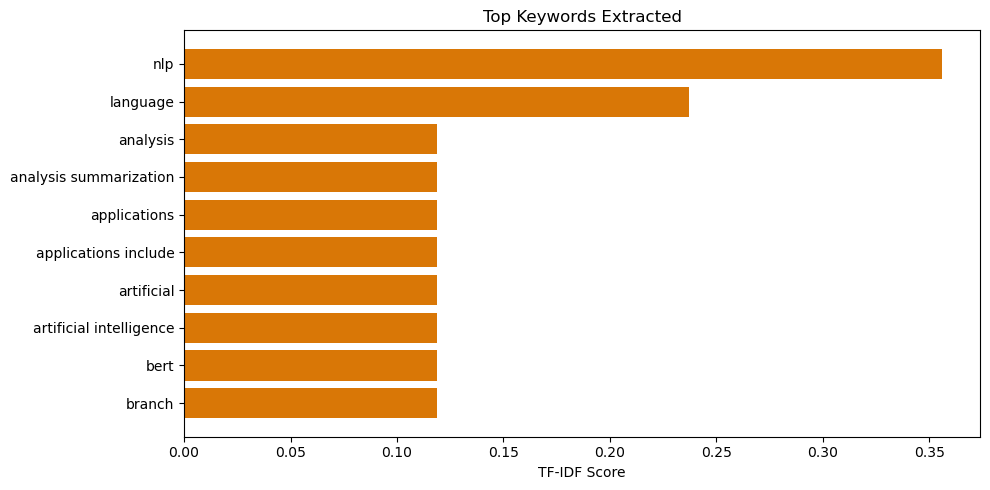

In [3]:
#App3 Keyword Extraction

# Cell 1 — Install & Import
!pip install nltk scikit-learn matplotlib pandas
import nltk, string, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

# Cell 2 — Sample Text (replace with any text)
text = """
Natural Language Processing (NLP) is a branch of artificial intelligence.
NLP helps computers understand, interpret and generate human language.
Applications include chatbots, translation, sentiment analysis, and summarization.
Machine learning models power modern NLP systems like transformers and BERT.
"""

# Cell 3 — Keyword Extraction Function
def extract_keywords(text, top_n=10):
    stop_words = list(stopwords.words('english'))
    vectorizer  = TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform([text])
    scores = dict(zip(vectorizer.get_feature_names_out(),
                      tfidf_matrix.toarray()[0]))
    sorted_kw = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_kw[:top_n]

# Cell 4 — Extract & Display
keywords = extract_keywords(text, top_n=10)
df = pd.DataFrame(keywords, columns=['Keyword', 'TF-IDF Score'])
df['TF-IDF Score'] = df['TF-IDF Score'].round(4)
print(df.to_string(index=False))

# Cell 5 — Visualize
words  = [k[0] for k in keywords]
scores = [k[1] for k in keywords]
plt.figure(figsize=(10, 5))
plt.barh(words[::-1], scores[::-1], color='#D97706')
plt.xlabel('TF-IDF Score')
plt.title('Top Keywords Extracted')
plt.tight_layout()
plt.show()